### 1. Importing Libraries

In [1]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
import scipy.stats
import pylab

import sklearn
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
from sklearn.pipeline import Pipeline
import plotly.express as px
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
import cufflinks as cf
cf.go_offline()
cf.set_config_file(offline=False, world_readable=True)

from sklearn.metrics import make_scorer, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

pd.options.display.max_columns = None
pd.options.display.max_rows = None



/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


/opt/conda/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.9.1-CAPI-1.14.2) is incompatible with the GEOS version PyGEOS was compiled with (3.10.3-CAPI-1.16.1). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


**Introduction**

This was my first submission in kaggle a few months back when I was very new to this platform.

After exploring Kaggle and it's inner workings, I decided to re-visit this contest so as to improve my score on my first ever notebook.

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

## 2. Importing Data

In [2]:
train=pd.read_csv('/kaggle/input/titanic/train.csv')
test=pd.read_csv('/kaggle/input/titanic/test.csv')

In [3]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [4]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


Age, Cabin and Embarked have Missing Values

## 3. Missing Values and Qualitative Assessment

### 3.1 Age - Missing Values

In [5]:
a=train['Age'].isna().sum()
print("The no of missing values in age are: ",a)
b=len(train['Age'])

print(f'This is {(a/b)*100} % of the values')
px.histogram(train['Age'],marginal='box')

The no of missing values in age are:  177
This is 19.865319865319865 % of the values


Since "Age" is (right) skewed, imputing the mean values may give us biased results so we will impute the median.

In [6]:
print('Median age is ',train['Age'].median(skipna=True))
print('Mean age is ',train['Age'].mean(skipna=True))

Median age is  28.0
Mean age is  29.69911764705882


In [7]:
print('Null Values before: ',train['Age'].isna().sum())
train['Age'].fillna(train['Age'].median(),inplace=True)
print('Null Values after: ',train['Age'].isna().sum())

Null Values before:  177
Null Values after:  0


### 3.2 Embarked - Missing values

In [8]:
a=train['Embarked'].isna().sum()
b=len(train['Embarked'])
print("No of missing vlues: ",a)
print(f"This is {(round(a/b,4))*100} % of the values")
print("This is not bad, we can simply drop these values")

No of missing vlues:  2
This is 0.22 % of the values
This is not bad, we can simply drop these values


In [9]:
px.histogram(train['Embarked'],color_discrete_sequence=[['red','green','blue']],title='Embarked')

Looking at the above vsualization, we should **impute the mode in the missing instances**

In [10]:
print("No of missing values before = ",train['Embarked'].isna().sum())
train["Embarked"].fillna("S", inplace=True)
print("No of missing values before = ",train['Embarked'].isna().sum())

No of missing values before =  2
No of missing values before =  0


### 3.3 Missing Values - Cabin

In [11]:
a=train['Cabin'].isna().sum()
print('No of missing values are: ', a)
b=len(train['Cabin'])
print(f'This is {round((a/b)*100,2)} % of the Values')

No of missing values are:  687
This is 77.1 % of the Values


- We need to ignore cabin as a variable 77% os it's values are null so it is neither useful nor can we fill it using some other variable

- Based on the information available, it appears that this value is associated with the passenger's class and fare paid.

In [12]:
train.drop('Cabin',axis=1,inplace=True)

### 3.4 Additional Variables. 

>SibSp and Parch relate to traveling with family. For simplicity we will combine this into one singular variable weather the individual is alone or not this will also allow for maximum possible collinearity

In [13]:
#Adding Alone to train set
train['T_partner']=train["SibSp"]+train["Parch"]
train['Alone']=np.where(train['T_partner']>0, 0, 1)

#These variables are useless now
train.drop('SibSp', axis=1, inplace=True)
train.drop('Parch', axis=1, inplace=True)
train.drop('T_partner', axis=1, inplace=True)

In [14]:
px.histogram(train['Alone'])

**PassengerID, Name and Ticket** are useless for prediction or imputation so we will drop these attributes

In [15]:
train.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

**Now we apply all these changes to the test data**

In [16]:
test["Age"].fillna(28, inplace=True)
test["Fare"].fillna(14.45, inplace=True)
test.drop('Cabin', axis=1, inplace=True)
test['T_partner']=test["SibSp"]+test["Parch"]
test['Alone']=np.where(test['T_partner']>0, 0, 1)

test.drop('SibSp', axis=1, inplace=True)
test.drop('Parch', axis=1, inplace=True)
test.drop('T_partner', axis=1, inplace=True)

In [17]:
test.drop('PassengerId', axis=1, inplace=True)
test.drop('Name', axis=1, inplace=True)
test.drop('Ticket', axis=1, inplace=True)

In [18]:
test.head()

,Pclass,Sex,Age,Fare,Embarked,Alone
0,3,male,34.5,7.8292,Q,1
1,3,female,47.0,7.0000,S,0
2,2,male,62.0,9.6875,Q,1
3,3,male,27.0,8.6625,S,1
4,3,female,22.0,12.2875,S,0


## 4. Exploratory Data Analysis (EDA)

### 4.1 Age

In [19]:
px.histogram(train['Age'],color=train['Survived'])

> The age distribution for survivors and deceased is actually very similar. One notable difference is that, of the survivors, a larger proportion were children. The passengers evidently made an attempt to save children by giving them a place on the life rafts.

In [20]:
temp=train[['Age','Survived']]
a=temp.loc[(temp['Age']<16) & (temp['Survived'] == 1)]['Survived'].sum()/len(temp.loc[(temp['Age']<16)]['Survived'])
b=temp.loc[(temp['Age']>16) & (temp['Survived'] == 1)]['Survived'].sum()/len(temp.loc[(temp['Age']>16)]['Survived'])
temp=pd.DataFrame([[a,'Minor'],[b,'Adult']],columns=['Data', 'Minor/Adult'])
px.bar(temp,y='Data',x='Minor/Adult')

> As we can see the possibility of a minor surviving is much more than an adult
So it makes sense for a new **Is_Minor** attribute

In [21]:
train['is_minor']=np.where(train['Age']<=16,1,0)
test['is_minor']=np.where(test['Age']<=16,1,0)

### 4.2 Fare

In [22]:
#fig=go.Figure()
fig=ff.create_distplot([train[train.Survived==1]['Fare'],train[train.Survived==0]['Fare']],group_labels=['Survived','Not'])
fig.show()

At first the idea was to make a seperate feature that tells if a person didnt spend anything however, after making that feature I noticed that there were only a select few people that didnt spend anything, so I dropped it

### 4.3 Passenger Class

<AxesSubplot:xlabel='Pclass', ylabel='Survived'>

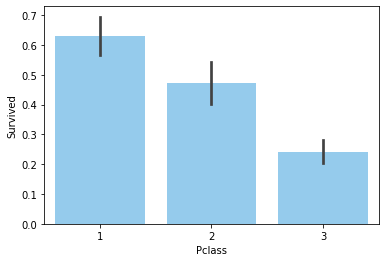

In [23]:
sns.barplot(x='Pclass', y='Survived', data=train,color='lightskyblue')

Being a first class passenger was safest, wow

### 4.4 Embarked Port

In [24]:
px.histogram(train['Embarked'])

Most people embarked from **'S'**

<AxesSubplot:xlabel='Embarked', ylabel='Survived'>

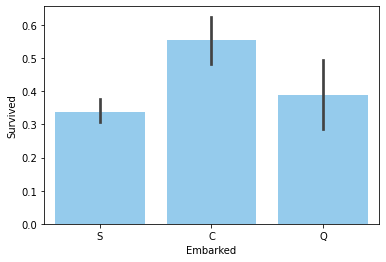

In [25]:
sns.barplot(x = 'Embarked', y = 'Survived', data = train,color='lightskyblue')

Most survivors are from C

### 4.5 Traveling Alone vs With Family

<AxesSubplot:xlabel='Alone', ylabel='Survived'>

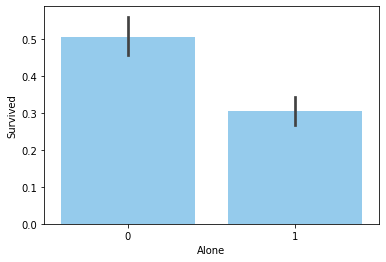

In [26]:
sns.barplot(x='Alone', y='Survived', data=train,color='lightskyblue')

From this: 
- Individuals travelling alone are more likely to die
- People travelling with family are moe likely to survive
- Given the era, these are mote likely to be male

## 5. Preprocessing

In [27]:
train.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Alone,is_minor
0,0,3,male,22.0,7.2500,S,0,0
1,1,1,female,38.0,71.2833,C,0,0
2,1,3,female,26.0,7.9250,S,1,0
3,1,1,female,35.0,53.1000,S,0,0
4,0,3,male,35.0,8.0500,S,1,0


In [28]:
cols=["Age", "Fare", "Alone","is_minor",'Pclass','Embarked','Sex'] 
X=train[cols]
y=train['Survived']

# Featuress thaat need to be transformed
feats=['Pclass','Sex','Embarked']

#import the nesscary libraries
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

#Build a column transformer
transformer=make_column_transformer(
    (OneHotEncoder(),
     feats),
    remainder='passthrough'
)

#Apply
X_s=transformer.fit_transform(X)
test_s=transformer.fit_transform(test)

## 6. Evaluating Estimators

### 6.1 Logistic regression

In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_s,y,
                                               test_size=0.25,
                                               random_state=0
                                              )

In [30]:
scores=[]
#This is a function to test the accuracy of a classifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
def classifier_accuracy(model):
    
    #the CV 5 fold score
    #x=cross_val_score(model, X_test,y_test,cv=5).mean()*100
    #print(f"5 Fold CV Accuracy = {x:.2f}%\n\n")
    
    #The ROC curve
    print("The ROC: ")
    y_probs=model.predict_proba(X_test)
    y_probs_positive=y_probs[:,1]
    fpr,tpr,thresholds=roc_curve(y_test,y_probs_positive)
    plt.plot(fpr,tpr,color="orange",label='ROC')
    plt.plot([0,1],[0,1],label="No predictive Power Line",linestyle='--')
    print(f"AUC: {roc_auc_score(y_test,y_probs_positive)*100:.2f}%")
    plt.ylabel("True Positive Rate")
    plt.xlabel("False Positive Rate")
    plt.legend()
    plt.show()
    
    
    #The confusion matrix
    print("The Confusion Matrix: ")
    y_preds=model.predict(X_test)
    conf_mat=confusion_matrix(y_test,y_preds)
    sns.heatmap(data = conf_mat,annot=True,fmt='d')
    plt.show()
    
    
    #classidication report
    print("Classification Report:-\n")
    print(classification_report(y_test,y_preds))

Model Accuracy : 79.82%
The ROC: 
AUC: 86.65%


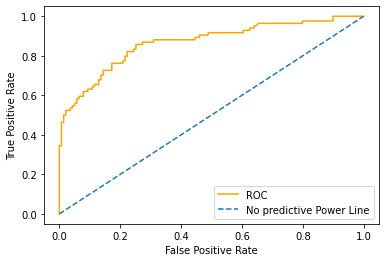

The Confusion Matrix: 


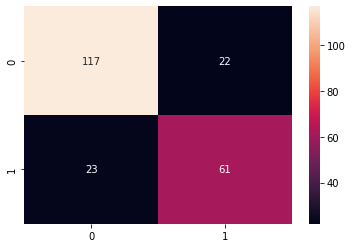

Classification Report:-

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       139
           1       0.73      0.73      0.73        84

    accuracy                           0.80       223
   macro avg       0.79      0.78      0.78       223
weighted avg       0.80      0.80      0.80       223



In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

logreg = LogisticRegression(max_iter=500)
logreg.fit(X_train, y_train)
#sys.stdout.write(GREEN)
print("Model Accuracy : {:.2f}%".format(logreg.score(X_test, y_test)*100))
scores.append(logreg.score(X_test,y_test))
classifier_accuracy(logreg)

>**In conclusion**
    Based on random forest you  are most likely to survive if you are:
    >- Female
    >- Young
    >- In first class
    >- Embarked from Cherbourg, France

### 6.2 Random Forest

> Random forests, a tree-based machine learning technique, often provide more accurate results than Logistic Regression classifier models. With respect to tree growth, performance tends to taper off after a certain number of trees are grown.

>A random forest is a meta estimator that fits a number of decision tree classifiers on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.

The ROC: 
AUC: 88.25%


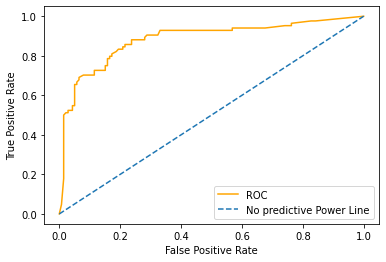

The Confusion Matrix: 


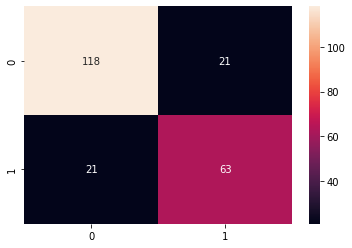

Classification Report:-

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       139
           1       0.75      0.75      0.75        84

    accuracy                           0.81       223
   macro avg       0.80      0.80      0.80       223
weighted avg       0.81      0.81      0.81       223



In [32]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(X_train,y_train)
scores.append(model.score(X_test,y_test))
classifier_accuracy(model)

**Creating a Submission**

In [33]:
y_pred_rf=model.predict(test_s)
test_pid=pd.read_csv('/kaggle/input/titanic/test.csv')
submission = pd.DataFrame({
        "PassengerId": test_pid["PassengerId"],
        "Survived": y_pred_rf
    })
submission.to_csv('titanic_RF.csv', index=False)

### 6.3 Descision Tree

> Decision Tree is the most powerful and popular tool for classification and prediction. A Decision tree is a flowchart-like tree structure, where each internal node denotes a test on an attribute, each branch represents an outcome of the test, and each leaf node (terminal node) holds a class label. 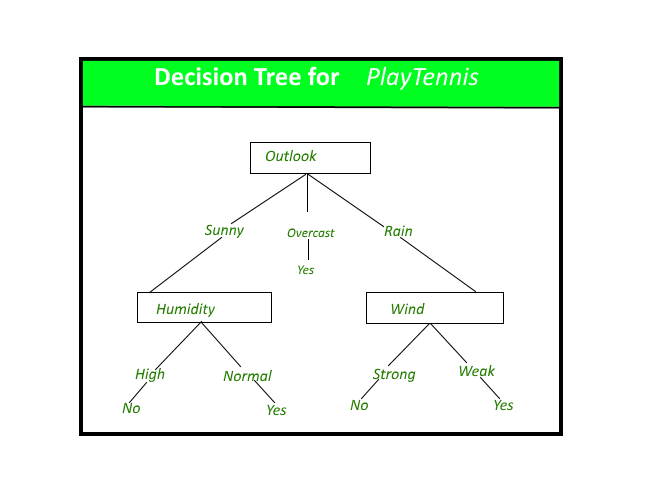

In [34]:
from sklearn import tree
import graphviz
tree1 = tree.DecisionTreeClassifier(criterion='gini',
                                    splitter='best',
                                    max_depth=3, 
                                    min_samples_leaf=20)

The ROC: 
AUC: 87.61%


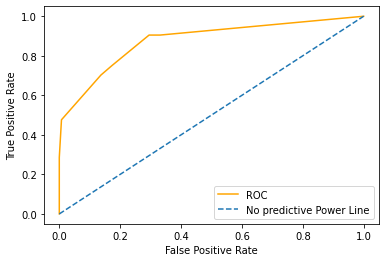

The Confusion Matrix: 


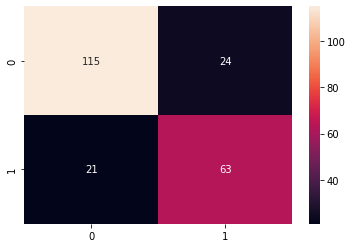

Classification Report:-

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       139
           1       0.72      0.75      0.74        84

    accuracy                           0.80       223
   macro avg       0.78      0.79      0.79       223
weighted avg       0.80      0.80      0.80       223



In [35]:
tree1.fit(X_train,y_train)
scores.append(tree1.score(X_test,y_test))
classifier_accuracy(tree1)

This Section was formerly named 'Experimental'

### 6.4 Genetic Algorithm

In [36]:
import sympy
from sympy import simplify, cos, sin, Symbol, Function, tanh, pprint, init_printing, exp
from sympy.functions import Min,Max

A = 0.058823499828577    
B = 0.841127 # 0.885868
C = 0.138462007045746 
D = 0.31830988618379069
E = 2.810815 # 2.675679922103882 
F = 0.63661977236758138
G = 5.428569793701172   
H = 3.1415926535897931
I = 0.592158 #0.623655974864960
J = 4.869778 #  2.770736 # 2.212120056152344
K = 0.063467 # 1.5707963267948966
L = -0.091481 # 0.094339601695538 
M = 0.0821533 
N = 0.720430016517639
O = 0.230145 
P = 9.89287 
Q = 785 
R = 1.07241 
S = 281
T = 734
U = 5.3
V = 67.0
W = 2.484848
X = 8.48635 
Y = 63
Z = 12.6275 
AA = 0.735354 # 0.7
AB = 727
AC = 2.5
AD = 2.6 
AE = 0.3
AF = 3.0
AG = 0.226263 #0.1
AH = 2.0
AI = 12.4148
AJ = 96
AK = 0.130303 # 0.2
AL = 176
AM = 3.2
BIG = [A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S,T,U,V,W,X,Y,Z,AA,AB,AC,AD,AE,AF,AG,AH,AI,AJ,AK,AL,AM]

In [37]:
# Now may I present: The winning gen function, Inspired by Akshat's notebook:
# https://www.kaggle.com/akshat113/titanic-dataset-analysis-level-2
def GeneticFunction(data,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S,T,U,V,W,X,Y,Z,AA,AB,AC,AD,AE,AF,AG,AH,AI,AJ,AK,AL,AM):
    return ((np.minimum( ((((A + data["Sex"]) - np.cos((data["Pclass"] / AH))) * AH)),  ((B))) * AH) +
            np.maximum( ((data["SibSp"] - AC)),  ( -(np.minimum( (data["Sex"]),  (np.sin(data["Parch"]))) * data["Pclass"]))) +
            (AG * ((np.minimum( (data["Sex"]),  (((data["Parch"] / AH) / AH))) * data["Age"]) - data["Cabin"])) +
            np.minimum( ((np.sin((data["Parch"] * ((data["Fare"] - AA) * AH))) * AH)),  ((data["SibSp"] / AH))) +
            np.maximum( (np.minimum( ( -np.cos(data["Embarked"])),  (C))),  (np.sin(((data["Cabin"] - data["Fare"]) * AH)))) +
            -np.minimum( ((((data["Age"] * data["Parch"]) * data["Embarked"]) + data["Parch"])),  (np.sin(data["Pclass"]))) +
            np.minimum( (data["Sex"]),  ((np.sin( -(data["Fare"] * np.cos((data["Fare"] * W)))) / AH))) +
            np.minimum( ((O)),  (np.sin(np.minimum( (((V / AH) * np.sin(data["Fare"]))),  (D))))) +
            np.sin((np.sin(data["Cabin"]) * (np.sin((Z)) * np.maximum( (data["Age"]),  (data["Fare"]))))) +
            np.sin(((np.minimum( (data["Fare"]),  ((data["Cabin"] * data["Embarked"]))) / AH) *  -data["Fare"])) +
            np.minimum( (((AD * data["SibSp"]) * np.sin(((AJ) * np.sin(data["Cabin"]))))),  (data["Parch"])) +
            np.sin(np.sin((np.maximum( (np.minimum( (data["Age"]),  (data["Cabin"]))),  ((data["Fare"] * AK))) * data["Cabin"]))) +
            np.maximum( (np.sin(((AI) * (data["Age"] / AH)))),  (np.sin((-AF * data["Cabin"])))) +
            (np.minimum( (np.sin((((np.sin(((data["Fare"] * AH) * AH)) * AH) * AH) * AH))),  (data["SibSp"])) / AH) +
            ((data["Sex"] - data["SibSp"]) * (np.cos(((data["Embarked"] - AA) + data["Age"])) / AH)) +
            ((np.sin(data["Cabin"]) / AH) - (np.cos(np.minimum( (data["Age"]),  (data["Embarked"]))) * np.sin(data["Embarked"]))) +
            np.minimum( (AE),  ((data["Sex"] * (J * (N - np.sin((data["Age"] * AH))))))) +
            (np.minimum( (np.cos(data["Fare"])),  (np.maximum( (np.sin(data["Age"])),  (data["Parch"])))) * np.cos((data["Fare"] / AH))) +
            np.sin((data["Parch"] * np.minimum( ((data["Age"] - K)),  ((np.cos((data["Pclass"] * AH)) / AH))))) +
            (data["Parch"] * (np.sin(((data["Fare"] * (I * data["Age"])) * AH)) / AH)) +
            (D * np.cos(np.maximum( ((0.5 * data["Fare"])),  ((np.sin(N) * data["Age"]))))) +
            (np.minimum( ((data["SibSp"] / AH)),  (np.sin(((data["Pclass"] - data["Fare"]) * data["SibSp"])))) * data["SibSp"]) +
            np.tanh((data["Sex"] * np.sin((U * np.sin((data["Cabin"] * np.cos(data["Fare"]))))))) +
            (np.minimum( (data["Parch"]),  (data["Sex"])) * np.cos(np.maximum( ((np.cos(data["Parch"]) + data["Age"])),  (AM)))) +
            (np.minimum( (np.tanh(((data["Cabin"] / AH) + data["Parch"]))),  ((data["Sex"] + np.cos(data["Age"])))) / AH) +
            (np.sin((np.sin(data["Sex"]) * (np.sin((data["Age"] * data["Pclass"])) * data["Pclass"]))) / AH) +
            (data["Sex"] * (np.cos(((data["Sex"] + data["Fare"]) * ((X) * (Y)))) / AH)) +
            np.minimum( (data["Sex"]),  ((np.cos((data["Age"] * np.tanh(np.sin(np.cos(data["Fare"]))))) / AH))) +
            (np.tanh(np.tanh( -np.cos((np.maximum( (np.cos(data["Fare"])),  (L)) * data["Age"])))) / AH) +
            (np.tanh(np.cos((np.cos(data["Age"]) + (data["Age"] + np.minimum( (data["Fare"]),  (data["Age"])))))) / AH) +
            (np.tanh(np.cos((data["Age"] * ((-AH + np.sin(data["SibSp"])) + data["Fare"])))) / AH) +
            (np.minimum( (((S) - data["Fare"])),  (np.sin((np.maximum( ((AL)),  (data["Fare"])) * data["SibSp"])))) * AH) +
            np.sin(((np.maximum( (data["Embarked"]),  (data["Age"])) * AH) * (((Q) * H) * data["Age"]))) +
            np.minimum( (data["Sex"]),  (np.sin( -(np.minimum( ((data["Cabin"] / AH)),  (data["SibSp"])) * (data["Fare"] / AH))))) +
            np.sin(np.sin((data["Cabin"] * (data["Embarked"] + (np.tanh( -data["Age"]) + data["Fare"]))))) +
            (np.cos(np.cos(data["Fare"])) * (np.sin((data["Embarked"] - ((T) * data["Fare"]))) / AH)) +
            ((np.minimum( (data["SibSp"]),  (np.cos(data["Fare"]))) * np.cos(data["SibSp"])) * np.sin((data["Age"] / AH))) +
            (np.sin((np.sin((data["SibSp"] * np.cos((data["Fare"] * AH)))) + (data["Cabin"] * AH))) / AH) +
            (((data["Sex"] * data["SibSp"]) * np.sin(np.sin( -(data["Fare"] * data["Cabin"])))) * AH) +
            (np.sin((data["SibSp"] * ((((G + V) * AH) / AH) * data["Age"]))) / AH) +
            (data["Pclass"] * (np.sin(((data["Embarked"] * data["Cabin"]) * (data["Age"] - (R)))) / AH)) +
            (np.cos((((( -data["SibSp"] + data["Age"]) + data["Parch"]) * data["Embarked"]) / AH)) / AH) +
            (D * np.sin(((data["Age"] * ((data["Embarked"] * np.sin(data["Fare"])) * AH)) * AH))) +
            ((np.minimum( ((data["Age"] * A)),  (data["Sex"])) - F) * np.tanh(np.sin(data["Pclass"]))) +
            -np.minimum( ((np.cos(((AB) * ((data["Fare"] + data["Parch"]) * AH))) / AH)),  (data["Fare"])) +
            (np.minimum( (np.cos(data["Fare"])),  (data["SibSp"])) * np.minimum( (np.sin(data["Parch"])),  (np.cos((data["Embarked"] * AH))))) +
            (np.minimum( (((data["Fare"] / AH) - E)),  (C)) * np.sin((K * data["Age"]))) +
            np.minimum( ((M)),  (((np.sin(data["Fare"]) + data["Embarked"]) - np.cos((data["Age"] * (P)))))))

In [38]:
def CleanData(data):
    # Sex
    data.drop(['Ticket', 'Name'], inplace=True, axis=1)
    data.Sex.fillna('0', inplace=True)
    data.loc[data.Sex != 'male', 'Sex'] = 0
    data.loc[data.Sex == 'male', 'Sex'] = 1
    # Cabin
    data.Cabin.fillna('0', inplace=True)
    data.loc[data.Cabin.str[0] == 'A', 'Cabin'] = 1
    data.loc[data.Cabin.str[0] == 'B', 'Cabin'] = 2
    data.loc[data.Cabin.str[0] == 'C', 'Cabin'] = 3
    data.loc[data.Cabin.str[0] == 'D', 'Cabin'] = 4
    data.loc[data.Cabin.str[0] == 'E', 'Cabin'] = 5
    data.loc[data.Cabin.str[0] == 'F', 'Cabin'] = 6
    data.loc[data.Cabin.str[0] == 'G', 'Cabin'] = 7
    data.loc[data.Cabin.str[0] == 'T', 'Cabin'] = 8
    # Embarked
    data.loc[data.Embarked == 'C', 'Embarked'] = 1
    data.loc[data.Embarked == 'Q', 'Embarked'] = 2
    data.loc[data.Embarked == 'S', 'Embarked'] = 3
    data.Embarked.fillna(0, inplace=True)
    data.fillna(-1, inplace=True)
    return data.astype(float)

# This function rounds values to either 1 or 0, because the GeneticFunction below returns floats and no
# definite values
def Outputs(data):
    return np.round(1.-(1./(1.+np.exp(-data))))

In [39]:
raw_train = pd.read_csv('/kaggle/input/titanic/train.csv')
raw_test = pd.read_csv('/kaggle/input/titanic/test.csv')

cleanedTrain = CleanData(raw_train)
cleanedTest = CleanData(raw_test)
# run a check on the Training dataset. See section "Programm your own gen. algorithm" below on how to 
# construct your own genetic algorithm
thisArray = BIG.copy()
testPredictions = Outputs(GeneticFunction(cleanedTrain,thisArray[0],thisArray[1],thisArray[2],thisArray[3],thisArray[4],thisArray[5],thisArray[6],thisArray[7],thisArray[8],thisArray[9],thisArray[10],thisArray[11],thisArray[12],thisArray[13],thisArray[14],thisArray[15],thisArray[16],thisArray[17],thisArray[18],thisArray[19],thisArray[20],thisArray[21],thisArray[22],thisArray[23],thisArray[24],thisArray[25],thisArray[26],thisArray[27],thisArray[28],thisArray[29],thisArray[30],thisArray[31],thisArray[32],thisArray[33],thisArray[34],thisArray[35],thisArray[36],thisArray[37],thisArray[38]))
pdcheck = pd.DataFrame({'Survived': testPredictions.astype(int)})
ret = pdcheck.Survived.where(pdcheck["Survived"].values==cleanedTrain["Survived"].values).notna()
t,f = ret.value_counts()
score = 100/(t+f)*t
print("Training set score: ",score)
scores.append(score/100)

Training set score:  92.70482603815937


In [40]:
testPredictions = Outputs(GeneticFunction(cleanedTest,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S,T,U,V,W,X,Y,Z,AA,AB,AC,AD,AE,AF,AG,AH,AI,AJ,AK,AL,AM))
pdtest = pd.DataFrame({'PassengerId': cleanedTest.PassengerId.astype(int),
                        'Survived': testPredictions.astype(int)})
pdtest.to_csv('submission.csv', index=False)
pdtest.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


**Cheers**

In [41]:
models=['Logistic Regression',
        'Random Forest', 
        'Descision Tree',
        'Genetic Algorithm']
mod_analysis=pd.DataFrame(list(zip(models,scores)),columns=['Score',"Model"])

In [42]:
px.histogram(mod_analysis,x='Score',y='Model')

As we can see the genetic algorithm has a clear edge